# 📇 Model Card Generator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/model-card-gen/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/model-card-gen/demo.ipynb)

> **"No model documentation."**

A model with no card is a black box: nobody downstream knows what it's *for*, what it was *trained on*, how it *performs*, or where it *breaks*. This notebook auto-generates a **Google-style Model Card** in Markdown — introspecting everything the estimator can tell us and prompting for the human context (intent, data provenance, ethics) it can't.

**What we cover**
1. Train a churn classifier on synthetic data
2. Score it — overall + **per-slice** (fairness/robustness check)
3. Generate a full Model Card from the trained object
4. Visualize per-group performance
5. Export `MODEL_CARD.md`


## Step 1 — Train a model to document

We train a `RandomForestClassifier` to predict customer churn. `region` is held *out* of the feature matrix but kept aside so we can slice performance by it later — the classic fairness check.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)
n = 1500
df = pd.DataFrame({
    "tenure_months": rng.integers(1, 72, n),
    "monthly_spend": rng.normal(60, 20, n).round(2),
    "support_tickets": rng.poisson(1.5, n),
    "region": rng.choice(["North", "South", "East", "West"], n),
})
logit = -2.0 - 0.03 * df["tenure_months"] + 0.4 * df["support_tickets"]
df["churned"] = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

features = ["tenure_months", "monthly_spend", "support_tickets"]
X_tr, X_te, y_tr, y_te, _, region_te = train_test_split(
    df[features], df["churned"], df["region"], test_size=0.3, random_state=42, stratify=df["churned"])
model = RandomForestClassifier(n_estimators=120, max_depth=6, random_state=42).fit(X_tr, y_tr)
print(f"Trained on {len(X_tr)} rows, testing on {len(X_te)}. Churn rate: {df['churned'].mean():.1%}")

Trained on 1050 rows, testing on 450. Churn rate: 9.4%


## Step 2 — Score, overall and by slice

`compute_metrics` picks classification vs regression metrics automatically (via `is_classifier`), and breaks them down by any aligned slice series you pass — here, `region`.

In [2]:
from sklearn.base import is_classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def compute_metrics(model, X_test, y_test, slices=None):
    y_test = np.asarray(y_test)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    overall = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    slice_df = None
    if slices is not None:
        ev = pd.DataFrame({"y_true": y_test, "y_pred": y_pred, "slice": np.asarray(slices)})
        rows = []
        for grp, g in ev.groupby("slice"):
            rows.append({
                "slice": grp,
                "n": len(g),
                "accuracy": accuracy_score(g.y_true, g.y_pred),
                "f1": f1_score(g.y_true, g.y_pred, average="weighted", zero_division=0),
            })
        slice_df = pd.DataFrame(rows).set_index("slice")
    return overall, slice_df

overall, slice_df = compute_metrics(model, X_te, y_te, slices=region_te)
print("Overall:")
for k, v in overall.items():
    print(f"  {k:>10}: {v:.4f}")
print("\nBy region:")
slice_df

Overall:
    accuracy: 0.9089
   precision: 0.9172
      recall: 0.9089
          f1: 0.8676
     roc_auc: 0.7267

By region:


,n,accuracy,f1
slice,,,
East,114,0.877193,0.819807
North,129,0.922481,0.891756
South,96,0.927083,0.892005
West,111,0.909910,0.866990


## Step 3 — Generate the Model Card

The generator introspects the estimator (algorithm, hyperparameters) and fills the quantitative sections. You supply the human context — intended use, training data, ethics — so the card is never silently blank.

In [3]:
from model_card import generate_model_card

card = generate_model_card(
    model, X_te, y_te,
    model_name="Customer Churn Classifier",
    version="1.0.0",
    owners="Retention Analytics Team",
    intended_use="Flag customers at risk of churning for proactive retention outreach.",
    training_data="1,500 synthetic customer records (tenure, spend, support tickets, region).",
    slices=region_te, slice_name="region",
)
print(card[:1400], "\n... [truncated]")

# Model Card: Customer Churn Classifier

> Flag customers at risk of churning for proactive retention outreach.

| Field | Value |
|---|---|
| Model name | Customer Churn Classifier |
| Version | 1.0.0 |
| Owners | Retention Analytics Team |
| Task | classification |
| Algorithm | `RandomForestClassifier` |
| Test set size | 450 rows |

## Intended Use
Flag customers at risk of churning for proactive retention outreach.

**Out of scope:** any use not described above. Re-validate before applying to a new
population, time period, or decision context.

## Training Data
1,500 synthetic customer records (tenure, spend, support tickets, region).

## Model Details
| Hyperparameter | Value |
|---|---|
| `bootstrap` | True |
| `ccp_alpha` | 0.0000 |
| `class_weight` | None |
| `criterion` | gini |
| `max_depth` | 6 |
| `max_features` | sqrt |
| `max_leaf_nodes` | None |
| `max_samples` | None |
| `min_impurity_decrease` | 0.0000 |
| `min_samples_leaf` | 1 |
| `min_samples_split` | 2 |
| `min_we

## Step 4 — Visualize per-slice performance

The whole reason to slice: catch a group the model quietly underserves. A flat bar chart makes gaps obvious at a glance.

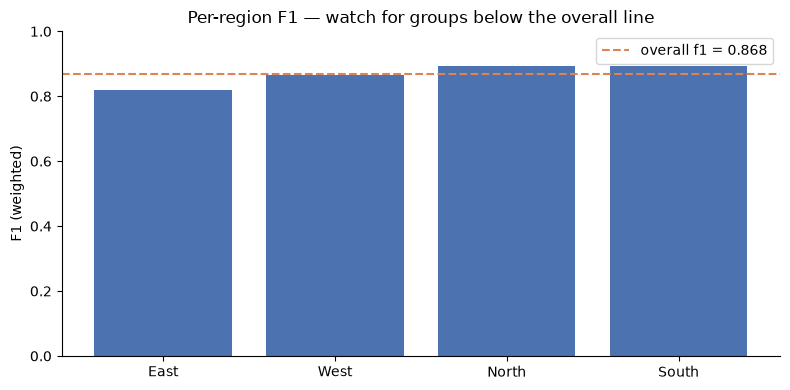

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
sl = slice_df.sort_values("f1")
ax.bar(sl.index, sl["f1"], color="#4C72B0")
ax.axhline(overall["f1"], color="#DD8452", ls="--", label=f"overall f1 = {overall['f1']:.3f}")
ax.set_ylabel("F1 (weighted)"); ax.set_ylim(0, 1)
ax.set_title("Per-region F1 — watch for groups below the overall line")
ax.legend()
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig("slice_perf.png", dpi=150, bbox_inches="tight"); plt.show()

## Step 5 — Export the card

Write it next to your model artifact and commit it. Now the model is documented.

In [5]:
with open("MODEL_CARD.md", "w") as f:
    f.write(card)
print("Wrote MODEL_CARD.md ({} chars)".format(len(card)))

Wrote MODEL_CARD.md (2108 chars)


## Summary

- A Model Card = the estimator's introspectable facts **+** the human context only you know.
- **Always slice** performance by a sensitive/segment attribute — the overall number hides the group the model fails.
- The card ends with a *"human review required"* footer: generation is a first draft, not a sign-off.
- Same function handles regression (auto-switches to RMSE/MAE/R²) via `is_classifier`.

## 🔧 Try Your Own

Point it at your own trained model + test set:

In [6]:
# from model_card import generate_model_card
# card = generate_model_card(
#     your_model, X_test, y_test,
#     model_name="Your Model",
#     intended_use="What decision this model supports, and for whom.",
#     training_data="Source, size, date range, known biases.",
#     slices=your_sensitive_column,   # aligned to X_test; optional
#     slice_name="group",
#     limitations=["Only validated on 2025 data.", "..."],
#     ethical_considerations=["Audited for disparate impact on ...", "..."],
# )
# print(card)

---

Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — a daily FDE portfolio (Day 75 of 120).

**Prefer a UI?** Run the Streamlit app: `pip install -r requirements.txt && streamlit run app.py` — fill the fields, see the card render live, download `MODEL_CARD.md`.